In [11]:
import zipfile
import io

zip_path = r'c:\Users\Number One\Desktop\gradproject\PRIDE dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    with outer_zip.open('PRIDE dataset/User1.zip') as user_file:
        with zipfile.ZipFile(io.BytesIO(user_file.read())) as inner_zip:
            files = inner_zip.namelist()
            print(f"جوا User1.zip:")
            for f in files:
                print(f)
                

جوا User1.zip:
User1/
User1/Dataset/
User1/Dataset/ACDS.csv
User1/Dataset/NCDS.csv
User1/FiveFoldCrossValidation/
User1/FiveFoldCrossValidation/Fold1/
User1/FiveFoldCrossValidation/Fold1/testing.csv
User1/FiveFoldCrossValidation/Fold1/training.csv
User1/FiveFoldCrossValidation/Fold2/
User1/FiveFoldCrossValidation/Fold2/testing.csv
User1/FiveFoldCrossValidation/Fold2/training.csv
User1/FiveFoldCrossValidation/Fold3/
User1/FiveFoldCrossValidation/Fold3/testing.csv
User1/FiveFoldCrossValidation/Fold3/training.csv
User1/FiveFoldCrossValidation/Fold4/
User1/FiveFoldCrossValidation/Fold4/testing.csv
User1/FiveFoldCrossValidation/Fold4/training.csv
User1/FiveFoldCrossValidation/Fold5/
User1/FiveFoldCrossValidation/Fold5/testing.csv
User1/FiveFoldCrossValidation/Fold5/training.csv


In [ ]:
import zipfile
import io
import pandas as pd

zip_path = r'c:\Users\Number One\Desktop\gradproject\PRIDE dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    with outer_zip.open('PRIDE dataset/User1.zip') as user_file:
        with zipfile.ZipFile(io.BytesIO(user_file.read())) as inner_zip:
            
            with inner_zip.open('User1/Dataset/NCDS.csv') as f:
                df_ncds = pd.read_csv(f, header=None)
            
            
            with inner_zip.open('User1/Dataset/ACDS.csv') as f:
                df_acds = pd.read_csv(f, header=None)

print(f"NCDS: {df_ncds.shape}")
print(f"ACDS: {df_acds.shape}")
print(f"\nأول 3 rows من NCDS:")
print(df_ncds.head(3))

NCDS: (466175, 26)
ACDS: (770, 27)

أول 3 rows من NCDS:
         0         1         2         3         4         5          6   \
0 -0.631104  0.000000 -0.750488  0.000000  0.233643  0.000000   0.213415   
1 -0.625977  0.006681 -0.740548  0.030509  0.252441  0.032261  16.184669   
2 -0.632355  0.065623 -0.739258  0.068096  0.275452  0.046768  34.687501   

          7          8          9   ...        16        17  18     19   20  \
0   0.000000  -0.548781   0.000000  ...  0.233643  0.000000  71  31.37  0.0   
1  14.322033  12.543554  15.172288  ...  0.252441  0.032261  71  31.37  0.0   
2  12.915299  42.389484  17.215813  ...  0.275452  0.046768  72  31.37  0.0   

    21   22   23   24  25  
0  0.0  0.0  0.0  0.0   0  
1  0.0  0.0  0.0  0.0   0  
2  0.0  0.0  0.0  0.0   0  

[3 rows x 26 columns]


In [ ]:
import zipfile
import io
import pandas as pd

zip_path = r'c:\Users\Number One\Desktop\gradproject\PRIDE dataset.zip'

DAYS = 4
ROWS_PER_DAY = 79_200
ROWS_TO_KEEP = DAYS * ROWS_PER_DAY  # 316,800

with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    with outer_zip.open('PRIDE dataset/User1.zip') as user_file:
        with zipfile.ZipFile(io.BytesIO(user_file.read())) as inner_zip:
            
         
            with inner_zip.open('User1/Dataset/NCDS.csv') as f:
                df_ncds = pd.read_csv(f, header=None)
                df_ncds = df_ncds.head(ROWS_TO_KEEP)
            
          
            with inner_zip.open('User1/Dataset/ACDS.csv') as f:
                df_acds = pd.read_csv(f, header=None)

print(f"NCDS كاملة الأصل: محدودة بـ {ROWS_TO_KEEP:,} row")
print(f"NCDS بعد التقليص: {df_ncds.shape}")
print(f"ACDS كاملة: {df_acds.shape}")
print(f"\nأول 3 rows من NCDS:")
print(df_ncds.head(3))

NCDS كاملة الأصل: محدودة بـ 316,800 row
NCDS بعد التقليص: (316800, 26)
ACDS كاملة: (770, 27)

أول 3 rows من NCDS:
         0         1         2         3         4         5          6   \
0 -0.631104  0.000000 -0.750488  0.000000  0.233643  0.000000   0.213415   
1 -0.625977  0.006681 -0.740548  0.030509  0.252441  0.032261  16.184669   
2 -0.632355  0.065623 -0.739258  0.068096  0.275452  0.046768  34.687501   

          7          8          9   ...        16        17  18     19   20  \
0   0.000000  -0.548781   0.000000  ...  0.233643  0.000000  71  31.37  0.0   
1  14.322033  12.543554  15.172288  ...  0.252441  0.032261  71  31.37  0.0   
2  12.915299  42.389484  17.215813  ...  0.275452  0.046768  72  31.37  0.0   

    21   22   23   24  25  
0  0.0  0.0  0.0  0.0   0  
1  0.0  0.0  0.0  0.0   0  
2  0.0  0.0  0.0  0.0   0  

[3 rows x 26 columns]


In [14]:
import zipfile
import io
import pandas as pd
import numpy as np
import os


zip_path = r'c:\Users\Number One\Desktop\gradproject\PRIDE dataset.zip'
output_dir = 'processed_batches'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
# names of the columns based on the dataset description
columns = [
    'gyro_acc_x_mean', 'gyro_acc_x_std', 'gyro_acc_y_mean', 'gyro_acc_y_std',
    'gyro_acc_z_mean', 'gyro_acc_z_std', 'gyro_vel_x_mean', 'gyro_vel_x_std',
    'gyro_vel_y_mean', 'gyro_vel_y_std', 'gyro_vel_z_mean', 'gyro_vel_z_std',
    'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std',
    'acc_z_mean', 'acc_z_std', 'heart_rate', 'skin_temp',
    'delta_steps', 'delta_distance', 'speed', 'pace',
    'delta_calories', 'uv'
]

def preprocess_batch(df, label, user_id):
    """
    Function to perform preprocessing on each batch individually
    """
    # adds a label column (1 for atypical, 0 for typical)
    df['label'] = 1 if label == 'atypical' else 0
    df['user_id'] = user_id
    
    df['acc_mag'] = np.sqrt(df['acc_x_mean']**2 + df['acc_y_mean']**2 + df['acc_z_mean']**2)
    
    # 3. handling Noise - Smoothing the heart rate using a rolling mean
    df['hr_smooth'] = df['heart_rate'].rolling(window=5, min_periods=1).mean()
    
    return df

# Batch processing (User by User)
with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    for user_num in range(1, 24):
        print(f" Processing User {user_num}...")
        try:
            with outer_zip.open(f'PRIDE dataset/User{user_num}.zip') as user_file:
                with zipfile.ZipFile(io.BytesIO(user_file.read())) as inner_zip:
                    
                    # Normal Data (NCDS)
                    with inner_zip.open(f'User{user_num}/Dataset/NCDS.csv') as f:
                       
                        df_ncds = pd.read_csv(f, header=None, names=columns)
                        df_ncds = preprocess_batch(df_ncds, 'typical', user_num)
                        df_ncds.to_parquet(f"{output_dir}/user_{user_num}_ncds.parquet")
                        del df_ncds # مسح من الذاكرة
                        
                    # Anomaly Data (ACDS)
                    with inner_zip.open(f'User{user_num}/Dataset/ACDS.csv') as f:
                        df_acds = pd.read_csv(f, header=None, names=columns)
                        df_acds = preprocess_batch(df_acds, 'atypical', user_num)
                        df_acds.to_parquet(f"{output_dir}/user_{user_num}_acds.parquet")
                        del df_acds # مسح من الذاكرة
                        
            print(f"   User {user_num} Done and saved to Parquet.")
        except Exception as e:
            print(f"   Error with User {user_num}: {e}")

print("\n All batches processed and saved efficiently!")

🔄 Processing User 1...


   User 1 Done and saved to Parquet.
🔄 Processing User 2...
   User 2 Done and saved to Parquet.
🔄 Processing User 3...
   User 3 Done and saved to Parquet.
🔄 Processing User 4...
   User 4 Done and saved to Parquet.
🔄 Processing User 5...
   User 5 Done and saved to Parquet.
🔄 Processing User 6...
   User 6 Done and saved to Parquet.
🔄 Processing User 7...
   User 7 Done and saved to Parquet.
🔄 Processing User 8...
   User 8 Done and saved to Parquet.
🔄 Processing User 9...
   User 9 Done and saved to Parquet.
🔄 Processing User 10...
   User 10 Done and saved to Parquet.
🔄 Processing User 11...
   User 11 Done and saved to Parquet.
🔄 Processing User 12...
   User 12 Done and saved to Parquet.
🔄 Processing User 13...
   User 13 Done and saved to Parquet.
🔄 Processing User 14...
   User 14 Done and saved to Parquet.
🔄 Processing User 15...
   User 15 Done and saved to Parquet.
🔄 Processing User 16...
   User 16 Done and saved to Parquet.
🔄 Processing User 17...
   User 17 Done and saved

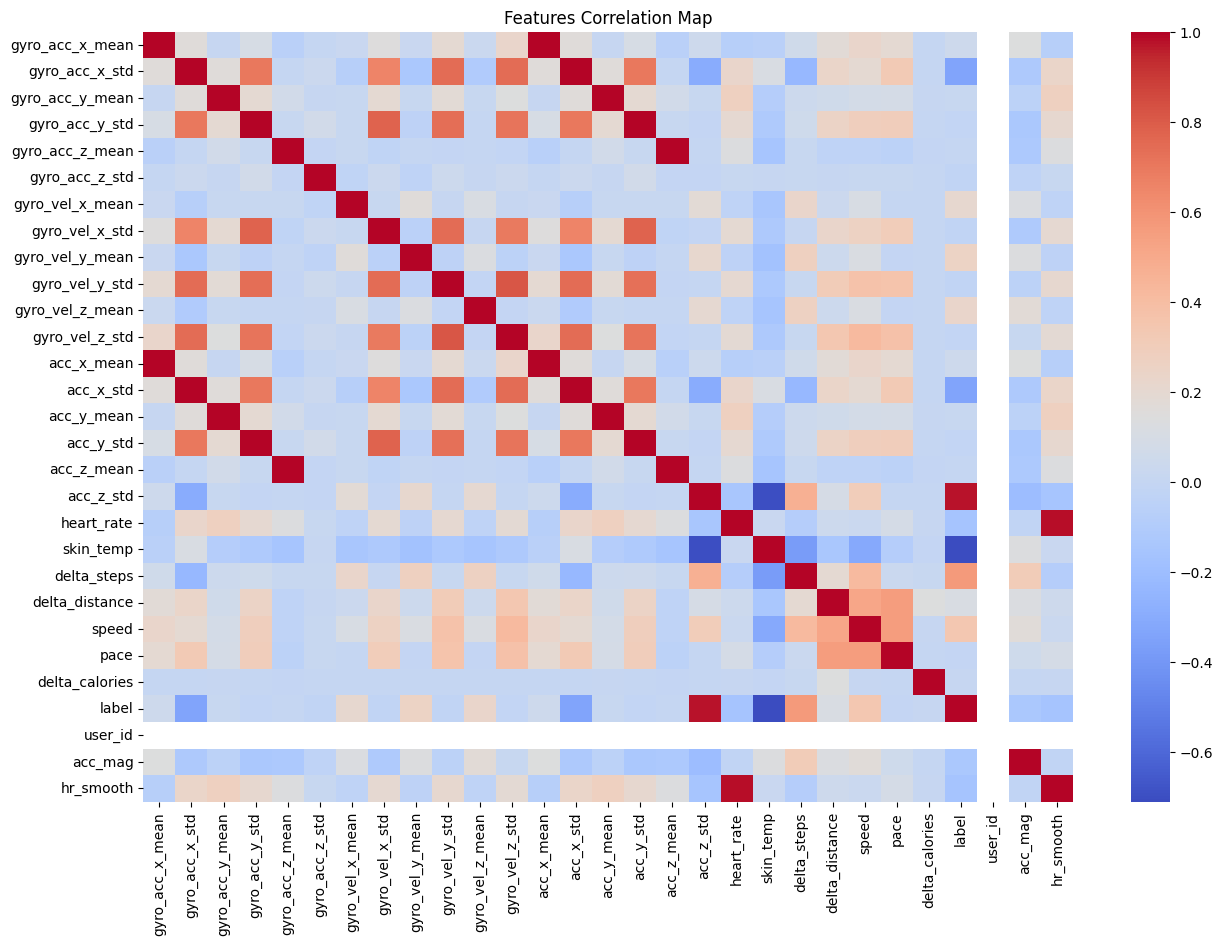

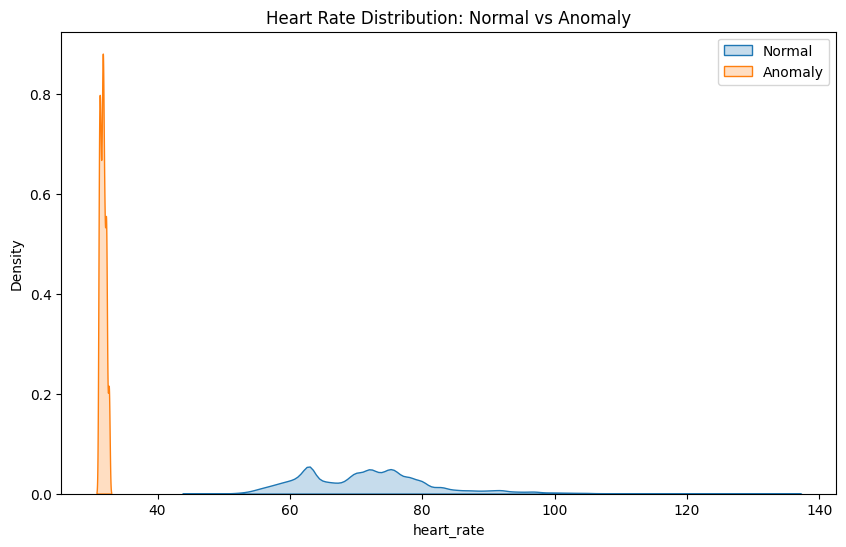

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# user one 
df_sample = pd.read_parquet('processed_batches/user_1_ncds.parquet')
df_anomaly = pd.read_parquet('processed_batches/user_1_acds.parquet')
full_sample = pd.concat([df_sample, df_anomaly])
plt.figure(figsize=(15, 10))
numeric_corr = full_sample.corr(numeric_only=True) 
sns.heatmap(numeric_corr, annot=False, cmap='coolwarm')
plt.title('Features Correlation Map')
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(df_sample['heart_rate'], label='Normal', fill=True)
sns.kdeplot(df_anomaly['heart_rate'], label='Anomaly', fill=True)
plt.title('Heart Rate Distribution: Normal vs Anomaly')
plt.legend()
plt.show()

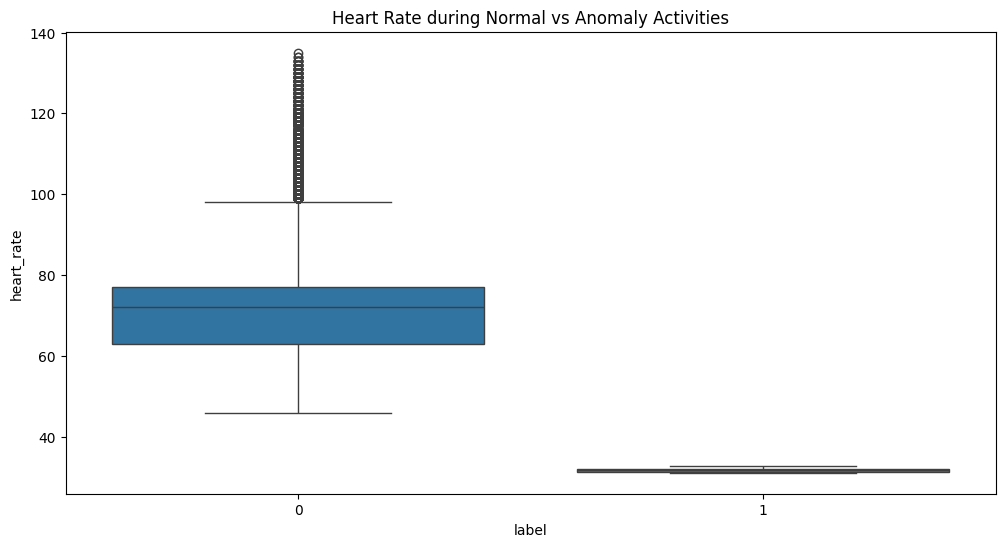

In [16]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='heart_rate', data=full_sample)
plt.title('Heart Rate during Normal vs Anomaly Activities')
plt.show()

In [ ]:
import os
import pandas as pd

input_dir = 'processed_batches'
all_summaries = []

for user_num in range(1, 24):
    ncds_path = f"{input_dir}/user_{user_num}_ncds.parquet"
    acds_path = f"{input_dir}/user_{user_num}_acds.parquet"
    
    if os.path.exists(ncds_path) and os.path.exists(acds_path):
      
        df_n = pd.read_parquet(ncds_path)
        df_a = pd.read_parquet(acds_path)
        
        summary = {
            'user': user_num,
            'normal_hr_mean': df_n['heart_rate'].mean(),
            'anomaly_hr_mean': df_a['heart_rate'].mean(),
            'normal_speed_mean': df_n['speed'].mean(), 
            'anomaly_speed_mean': df_a['speed'].mean(),
            'normal_acc_mag': df_n['acc_mag'].mean() if 'acc_mag' in df_n else 0, 
            'total_rows': len(df_n) + len(df_a)
        }
        all_summaries.append(summary)
      
        del df_n, df_a 


df_all_users = pd.DataFrame(all_summaries)
print(df_all_users)

    user  normal_hr_mean  anomaly_hr_mean  normal_speed_mean  \
0      1       71.855915        31.739390           4.991515   
1      2       64.426180        29.113421          11.246877   
2      3       71.488252        28.941599           7.145514   
3      4       68.335071        28.940975           3.871335   
4      5       68.911111        33.933321           5.678171   
5      6       66.159580        29.616187           5.123222   
6      7       74.341331        29.920909          17.294832   
7      8       65.662554        28.357528           5.117474   
8      9       81.414142        30.150777           4.310896   
9     10       77.573145        30.588801           5.343416   
10    11       72.383682        31.249335           3.476943   
11    12       71.343610        39.855523           5.965745   
12    13       71.831502        31.596784           9.247647   
13    14       70.741252        31.156876           8.549313   
14    15       71.080713        27.03934

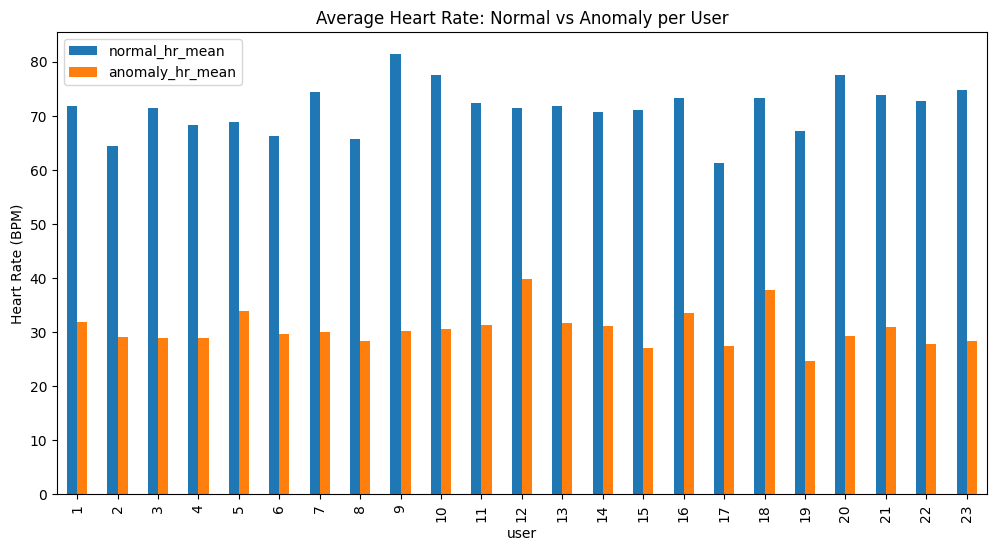

In [ ]:
import matplotlib.pyplot as plt


df_all_users.plot(x='user', y=['normal_hr_mean', 'anomaly_hr_mean'], kind='bar', figsize=(12,6))
plt.title('Average Heart Rate: Normal vs Anomaly per User')
plt.ylabel('Heart Rate (BPM)')
plt.show()

Scientific explanation: In medicine, a heart rate of 30 beats per minute is a very serious condition (bradycardia), or it may result from the sensor temporarily losing contact with the skin during the anomaly (for example, when the person falls and the device moves, preventing accurate measurement).

Technical explanation: This means that the anomaly in the dataset does not necessarily indicate a “high heart rate”; on the contrary, it could represent a sharp drop or a loss of signal caused by a sudden event.

In [ ]:
import os
import pandas as pd

input_dir = 'processed_batches'
all_summaries = []

for user_num in range(1, 24):
    ncds_path = f"{input_dir}/user_{user_num}_ncds.parquet"
    acds_path = f"{input_dir}/user_{user_num}_acds.parquet"
    
    if os.path.exists(ncds_path) and os.path.exists(acds_path):
        df_n = pd.read_parquet(ncds_path)
        df_a = pd.read_parquet(acds_path)
        
        for df in [df_n, df_a]:
            if 'acc_mag' not in df.columns:
              
                import numpy as np
                df['acc_mag'] = np.sqrt(df['acc_x_mean']**2 + df['acc_y_mean']**2 + df['acc_z_mean']**2)

        summary = {
            'user': user_num,
            'normal_hr_mean': df_n['heart_rate'].mean(),
            'anomaly_hr_mean': df_a['heart_rate'].mean(),
            'normal_acc_mag': df_n['acc_mag'].mean(), 
            'anomaly_acc_mag': df_a['acc_mag'].mean(),
            'total_rows': len(df_n) + len(df_a)
        }
        all_summaries.append(summary)
        del df_n, df_a 

df_all_users = pd.DataFrame(all_summaries)

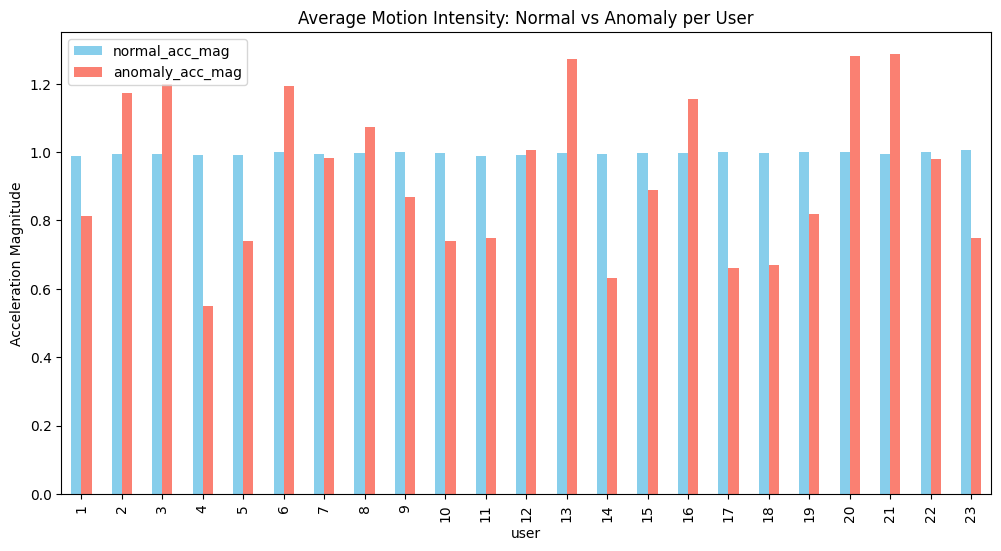

In [ ]:
import matplotlib.pyplot as plt

df_all_users.plot(x='user', y=['normal_acc_mag', 'anomaly_acc_mag'], kind='bar', color=['skyblue', 'salmon'], figsize=(12,6))
plt.title('Average Motion Intensity: Normal vs Anomaly per User')
plt.ylabel('Acceleration Magnitude')
plt.show()

Physical explanation: This is very logical, since the value of Earth’s gravity is approximately 1g1g1g. So, when the watch is at rest or in normal motion, it records gravity as a baseline value.
Fluctuation during the anomaly (orange): Here, we observe significant variation between users:


Users (2, 3, 6, 13, 20, 21): Their anomaly is associated with very intense motion (values above 1.2), which غالبًا represents a “fall” or sudden running.


Users (4, 14, 17): Their anomaly is associated with complete stillness or very weak motion (values below 0.8), which could represent “fainting” or the person remaining motionless for a long time after fatigue.



In [21]:

df_all_users.to_parquet('users_summary_stats.parquet')

Windowing